In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = pd.read_pickle(r"C:\Projects\ACUTEVIS\260503_ACUTEVIS_dataset.pkl")


In [2]:
print(dataset.columns.levels)

calcium = dataset['suite2p']['roi_fluorescence']

spont = pd.DataFrame([calcium.loc['SB18'], calcium.loc['SB19'], calcium.loc['SB20']], index=['SB18', 'SB19', 'SB20'])

spont = spont.drop(columns=[c for c in spont.columns if c[0] == 'ses-01'])

print(spont.keys())


[['encoder', 'notes', 'psychopy', 'pupil', 'pupil_meta', 'session_config', 'suite2p', 'time', 'timestamps', 'treadmill'], ['DOB', 'DOS', 'cell_identifier', 'cell_mask', 'click_delta', 'click_position', 'deltaf_f', 'device_elapsed_s', 'device_id', 'device_ts', 'distance_mm', 'duration', 'experiment_directory', 'experiment_id', 'experimentor', 'genotype', 'gratings_display_gratings.stopped', 'gratings_gratings_windows', 'gratings_gray_windows', 'gratings_stim_grating.started', 'gratings_stim_grating.stopped', 'gratings_stim_grayScreen.started', 'gratings_stim_grayScreen.stopped', 'gratings_trials.thisN', 'gratings_window_grating_start', 'gratings_window_grating_stop', 'gratings_window_gray_start', 'gratings_window_gray_stop', 'hardware_config_file', 'inj_vol', 'injection', 'meta', 'movies_description', 'movies_display_mov.started', 'movies_display_mov.stopped', 'movies_grey.started', 'movies_grey.stopped', 'movies_natural_mov.started', 'movies_thisRow.t', 'movies_trials.thisIndex', 'movi

In [3]:
dataset.suite2p.keys()

Index(['cell_identifier', 'stat', 'ops', 'plane_directory', 'cell_mask',
       'roi_fluorescence', 'neuropil_fluorescence', 'deltaf_f',
       'time_native_s', 'time_elapsed_s', 'meta'],
      dtype='object', name='Feature')

In [4]:
def subtract_neuropil(roi_arr, neuropil_arr, coeff=0.5):
    return roi_arr - coeff * neuropil_arr

def calculate_dff(arr):
    baseline = np.percentile(arr, 5, axis=1, keepdims=True)
    dff = (arr - baseline) / baseline
    return dff

def filter_low_baseline_rois(df, percentile=5, threshold=100):
    """
    Remove ROIs whose baseline (percentile-th percentile over time) is below
    `threshold` in ANY session. Returns a DataFrame with the same structure,
    where each array contains only the surviving ROIs.

    A ROI is identified by its row index within each array; the same row index
    is dropped across all sessions for a given subject.
    """
    filtered = df.copy()
    for subj in df.index:
        # Compute per-ROI baseline for every session and find the union of low ROIs
        low_roi_mask = None
        for col in df.columns:
            arr = df.loc[subj, col]
            if not isinstance(arr, np.ndarray) or arr.ndim < 2:
                continue
            baseline = np.percentile(arr, percentile, axis=1)  # (n_rois,)
            below = baseline < threshold
            low_roi_mask = below if low_roi_mask is None else (low_roi_mask | below)

        if low_roi_mask is None or not low_roi_mask.any():
            continue  # nothing to remove for this subject

        keep = ~low_roi_mask
        n_removed = low_roi_mask.sum()
        print(f"{subj}: removing {n_removed} ROI(s) with baseline < {threshold} "
              f"({keep.sum()} remaining)")

        for col in df.columns:
            arr = df.loc[subj, col]
            if isinstance(arr, np.ndarray) and arr.ndim >= 2:
                filtered.loc[subj, col] = arr[keep]

    return filtered

neuropil = pd.DataFrame(
    [dataset['suite2p']['neuropil_fluorescence'].loc[subj] for subj in spont.index],
    index=spont.index)

neuropil_sub = spont.copy()
for col in spont.columns:
    for subj in spont.index:
        neuropil_sub.loc[subj, col] = subtract_neuropil(spont.loc[subj, col], neuropil.loc[subj, col])

# neuropil_sub = filter_low_baseline_rois(neuropil_sub)
spont_dff = neuropil_sub.map(calculate_dff)


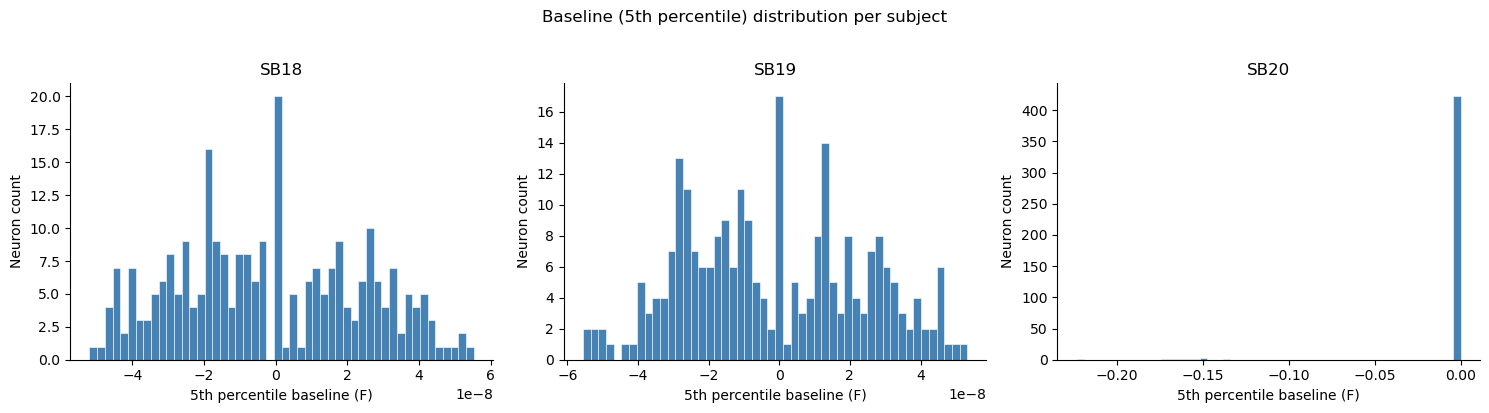

In [5]:
def plot_baseline_histograms(spont_df, percentile=5, bins=50):
    """
    Plot histogram of baseline percentile values per subject.
    The baseline is the `percentile`-th percentile along axis=0 for each
    (subject, session) array, giving one value per neuron per session.
    All sessions are pooled per subject.
    """
    subjects = spont_df.index
    n_subj = len(subjects)
    fig, axes = plt.subplots(1, n_subj, figsize=(5 * n_subj, 4), sharey=False)
    if n_subj == 1:
        axes = [axes]

    for ax, subj in zip(axes, subjects):
        baseline_vals = []
        for col in spont_df.columns:
            arr = spont_df.loc[subj, col]
            if arr is not None and isinstance(arr, np.ndarray) and arr.ndim >= 1:
                baseline_vals.append(np.percentile(arr, percentile, axis=1).ravel())
        if baseline_vals:
            all_vals = np.concatenate(baseline_vals)
            ax.hist(all_vals, bins=bins, color='steelblue', edgecolor='white', linewidth=0.4)
        ax.set_title(subj)
        ax.set_xlabel(f'{percentile}th percentile baseline (F)')
        ax.set_ylabel('Neuron count')
        ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle(f'Baseline ({percentile}th percentile) distribution per subject', y=1.02)
    plt.tight_layout()
    plt.show()

plot_baseline_histograms(spont_dff)


In [46]:
check = neuropil_sub['ses-04']['task-grayscreen']['SB20']
print(check)

np.isnan(check).sum()

[[4038.9438  3806.4314  3870.9084  ... 2193.0618  2104.5298  1964.6033 ]
 [2165.297   2090.3198  1793.4387  ... 2704.7869  2512.6543  2404.7283 ]
 [1587.8163  1748.947   1769.5294  ... 1652.9832  1462.8713  1372.5397 ]
 ...
 [1453.016   1365.6136  1475.9946  ... 1777.3096  1548.7665  1614.7727 ]
 [3080.1328  2897.4824  2775.9844  ... 2092.3247  2182.3052  1948.4946 ]
 [ 826.163    819.26843  787.81335 ...  834.944    762.0152   843.3817 ]]


np.int64(0)

In [36]:
def print_spont_shapes(df):
    for col in df.columns:
        for roi in df.index:
            val = df.loc[roi, col]
            shape = val.shape 
            print(f"{roi} | {col}: {shape}")

print_spont_shapes(neuropil_sub)


SB18 | ('ses-01', 'task-grayscreen'): (205, 36000)
SB19 | ('ses-01', 'task-grayscreen'): (231, 36000)
SB20 | ('ses-01', 'task-grayscreen'): (308, 36000)
SB18 | ('ses-02', 'task-grayscreen'): (88, 36000)
SB19 | ('ses-02', 'task-grayscreen'): (84, 36000)
SB20 | ('ses-02', 'task-grayscreen'): (144, 36000)
SB18 | ('ses-03', 'task-grayscreen'): (88, 36000)
SB19 | ('ses-03', 'task-grayscreen'): (84, 36000)
SB20 | ('ses-03', 'task-grayscreen'): (144, 36000)
SB18 | ('ses-04', 'task-grayscreen'): (88, 36000)
SB19 | ('ses-04', 'task-grayscreen'): (84, 36000)
SB20 | ('ses-04', 'task-grayscreen'): (144, 36000)


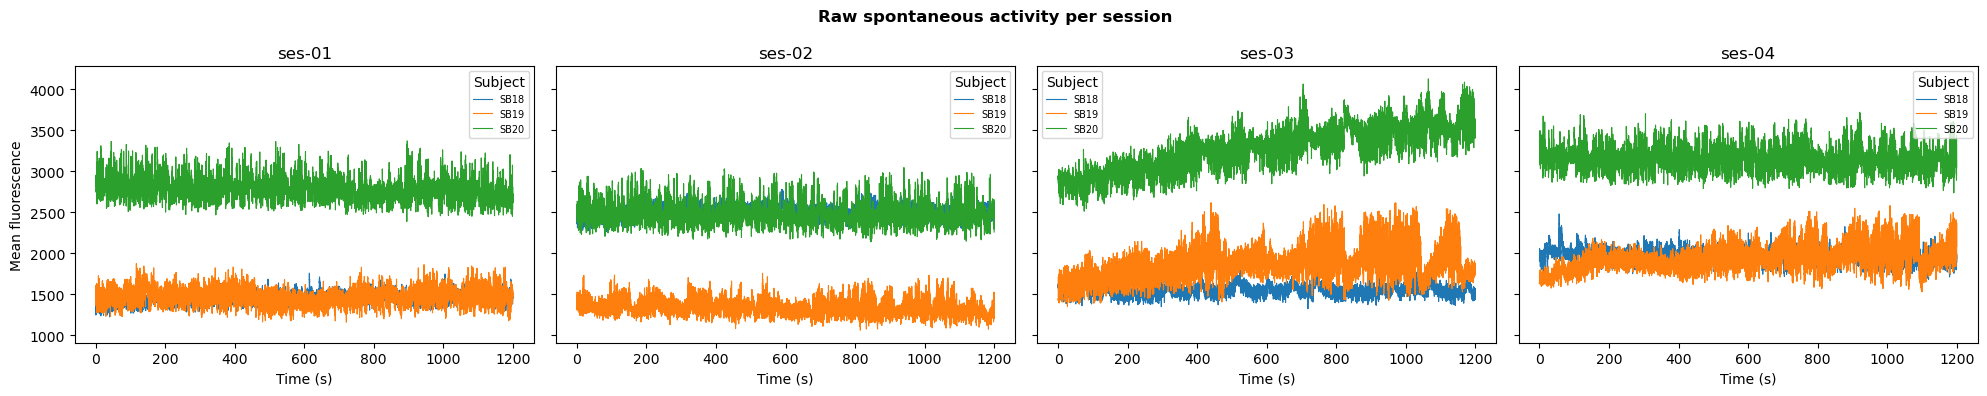

In [8]:
sessions = spont.columns.get_level_values('Session').unique()
fig, axes = plt.subplots(1, len(sessions), figsize=(5 * len(sessions), 4), sharey=True)

for ax, ses in zip(axes, sessions):
    ses_cols = [c for c in spont.columns if c[0] == ses]
    for subj in spont.index:
        trace = np.nanmean(
            np.concatenate([spont.loc[subj, col] for col in ses_cols], axis=1),
            axis=0
        )
        t = np.arange(len(trace)) / 30.0
        ax.plot(t, trace, linewidth=0.8, label=subj)
    ax.set_title(ses)
    ax.set_xlabel('Time (s)')
    ax.legend(title='Subject', fontsize=7)

axes[0].set_ylabel('Mean fluorescence')
fig.suptitle('Raw spontaneous activity per session', fontweight='bold')
plt.tight_layout()
plt.show()


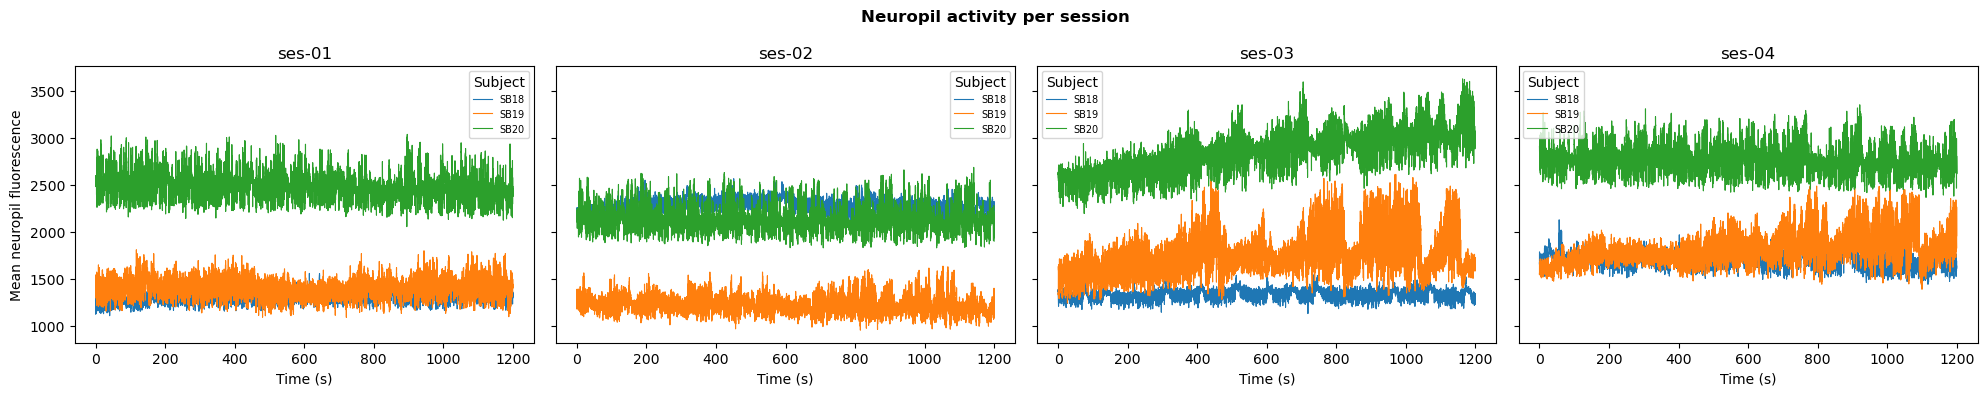

In [9]:
neuropil = pd.DataFrame(
    [dataset['suite2p']['neuropil_fluorescence'].loc[subj] for subj in spont.index],
    index=spont.index
)

sessions = neuropil.columns.get_level_values('Session').unique()
fig, axes = plt.subplots(1, len(sessions), figsize=(5 * len(sessions), 4), sharey=True)

for ax, ses in zip(axes, sessions):
    ses_cols = [c for c in neuropil.columns if c[0] == ses]
    for subj in neuropil.index:
        trace = np.nanmean(
            np.concatenate([neuropil.loc[subj, col] for col in ses_cols], axis=1),
            axis=0
        )
        t = np.arange(len(trace)) / 30.0
        ax.plot(t, trace, linewidth=0.8, label=subj)
    ax.set_title(ses)
    ax.set_xlabel('Time (s)')
    ax.legend(title='Subject', fontsize=7)

axes[0].set_ylabel('Mean neuropil fluorescence')
fig.suptitle('Neuropil activity per session', fontweight='bold')
plt.tight_layout()
plt.show()


In [37]:
from scipy.signal import find_peaks

peaks_df = neuropil_sub.copy()
for col in neuropil_sub.columns:
    for subject in neuropil_sub.index:
        arr = neuropil_sub.loc[subject, col]  # shape: (n_rois, n_timepoints)
        peaks_df.loc[subject, col] = [find_peaks(trace, prominence=1.0)[0] for trace in arr]

print(peaks_df)


Session                                             ses-01  \
Task                                       task-grayscreen   
SB18     [[1, 3, 6, 13, 17, 20, 22, 27, 29, 31, 33, 35,...   
SB19     [[2, 5, 7, 9, 11, 14, 17, 20, 24, 26, 28, 30, ...   
SB20     [[2, 5, 10, 15, 17, 21, 25, 27, 32, 36, 39, 42...   

Session                                             ses-02  \
Task                                       task-grayscreen   
SB18     [[3, 6, 8, 11, 14, 19, 22, 28, 31, 34, 39, 42,...   
SB19     [[3, 5, 10, 15, 18, 26, 29, 31, 34, 37, 39, 41...   
SB20     [[2, 6, 11, 13, 15, 17, 20, 24, 27, 31, 33, 37...   

Session                                             ses-03  \
Task                                       task-grayscreen   
SB18     [[2, 7, 9, 11, 16, 18, 20, 22, 25, 28, 31, 35,...   
SB19     [[1, 3, 7, 11, 17, 21, 23, 27, 30, 34, 36, 39,...   
SB20     [[4, 8, 10, 13, 17, 19, 22, 25, 30, 32, 34, 41...   

Session                                             ses-04  
Task  

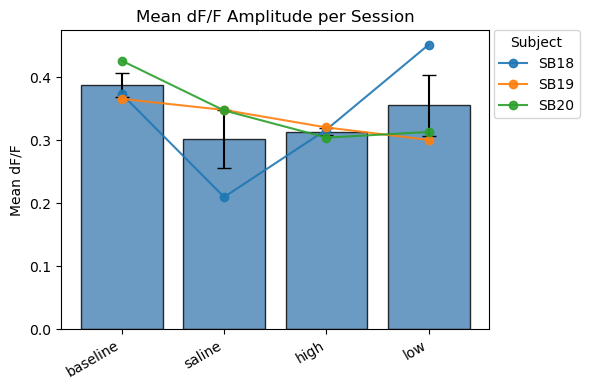

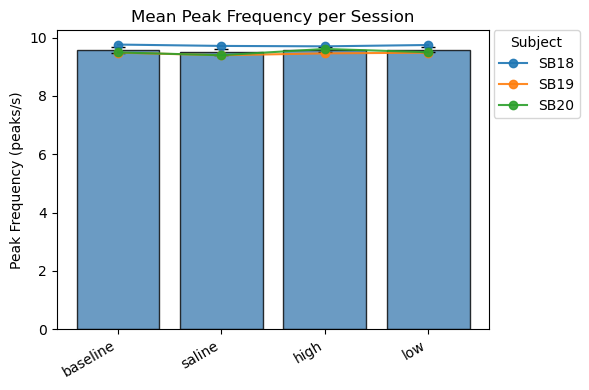

In [38]:
def get_injection_labels(dff_df, dataset):
    """Return injection label for each session column, using dataset.session_config.injection."""
    sc = dataset['session_config']['injection']
    labels = []
    for ses, _task in dff_df.columns:
        ses_vals = sc.xs(ses, level='Session')
        labels.append(ses_vals.iloc[0])
    return labels


def bar_plot(session_means, session_sems, session_labels, subject_values, subject_names, ylabel, title):
    """Bar plot: mean ± SEM bars with individual subject dots connected across sessions."""
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(session_labels))
    ax.bar(x, session_means, yerr=session_sems, capsize=5,
           color='steelblue', edgecolor='black', alpha=0.8)
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    subject_values_arr = np.array(subject_values)  # (n_sessions, n_subjects)
    for i_subj in range(subject_values_arr.shape[1]):
        vals = subject_values_arr[:, i_subj]
        color = colors[i_subj % len(colors)]
        ax.plot(x, vals, marker='o', color=color, linewidth=1.5, markersize=6,
                alpha=0.9, label=subject_names[i_subj])
    ax.set_xticks(x)
    ax.set_xticklabels(session_labels, rotation=30, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title='Subject', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.show()


def plot_mean_dff_amplitude(dff_df, dataset):
    """Bar plot of mean dF/F amplitude per session, labelled by injection identity."""
    sessions = dff_df.columns.get_level_values('Session').unique()
    inj_labels = get_injection_labels(dff_df, dataset)
    session_means, session_sems, all_subject_vals = [], [], []
    for ses in sessions:
        ses_cols = [c for c in dff_df.columns if c[0] == ses]
        subject_means = [
            np.nanmean([np.nanmean(dff_df.loc[subject, col]) for col in ses_cols])
            for subject in dff_df.index
        ]
        session_means.append(np.mean(subject_means))
        session_sems.append(np.std(subject_means, ddof=1) / np.sqrt(len(subject_means)))
        all_subject_vals.append(subject_means)
    bar_plot(session_means, session_sems, inj_labels, all_subject_vals,
             list(dff_df.index), ylabel='Mean dF/F', title='Mean dF/F Amplitude per Session')


def plot_mean_peak_frequency(pk_df, dff_df, dataset, fs=30.0):
    """Bar plot of mean peak frequency (peaks/s) per session, labelled by injection identity."""
    sessions = pk_df.columns.get_level_values('Session').unique()
    inj_labels = get_injection_labels(dff_df, dataset)
    session_means, session_sems, all_subject_vals = [], [], []
    for ses in sessions:
        ses_cols = [c for c in pk_df.columns if c[0] == ses]
        subject_means = []
        for subject in pk_df.index:
            roi_freqs = []
            for col in ses_cols:
                n_timepoints = dff_df.loc[subject, col].shape[1]
                duration_s = n_timepoints / fs
                roi_freqs.extend(len(p) / duration_s for p in pk_df.loc[subject, col])
            subject_means.append(np.mean(roi_freqs))
        session_means.append(np.mean(subject_means))
        session_sems.append(np.std(subject_means, ddof=1) / np.sqrt(len(subject_means)))
        all_subject_vals.append(subject_means)
    bar_plot(session_means, session_sems, inj_labels, all_subject_vals,
             list(pk_df.index), ylabel='Peak Frequency (peaks/s)', title='Mean Peak Frequency per Session')


# --- Call both plots ---
plot_mean_dff_amplitude(spont_dff, dataset)
plot_mean_peak_frequency(peaks_df, spont_dff, dataset, fs=30.0)


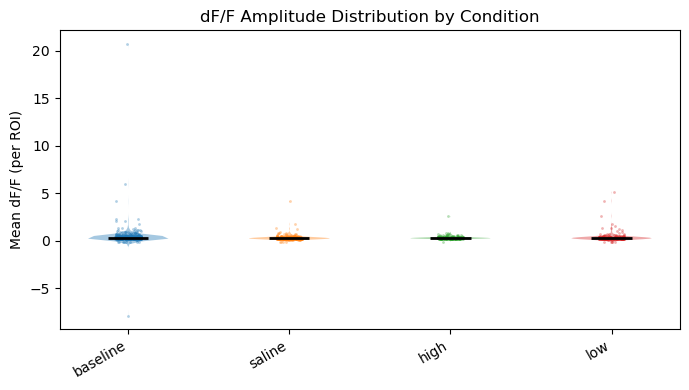

In [39]:
def plot_dff_violin(dff_df, dataset):
    """Violin plot of per-ROI mean dF/F amplitude, grouped by injection condition."""
    sc = dataset['session_config']['injection']
    rng = np.random.default_rng(0)

    condition_order = []
    data_by_condition = {}
    for ses, task in dff_df.columns:
        condition = sc.xs(ses, level='Session').iloc[0]
        if condition not in data_by_condition:
            data_by_condition[condition] = []
            condition_order.append(condition)
        for subject in dff_df.index:
            arr = dff_df.loc[subject, (ses, task)]  # (n_rois, n_timepoints)
            roi_means = np.nanmean(arr, axis=1)     # mean over time per ROI
            data_by_condition[condition].extend(roi_means.tolist())

    conditions = list(dict.fromkeys(condition_order))
    plot_data = [data_by_condition[c] for c in conditions]

    fig, ax = plt.subplots(figsize=(7, 4))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    parts = ax.violinplot(plot_data, positions=np.arange(len(conditions)),
                          showmedians=True, showextrema=False)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i % len(colors)])
        pc.set_alpha(0.4)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

    # Jittered individual ROI dots
    for i, (vals, color) in enumerate(zip(plot_data, colors)):
        vals = np.array(vals)
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(i + jitter, vals, s=4, color=color, alpha=0.35, linewidths=0)

    ax.set_xticks(np.arange(len(conditions)))
    ax.set_xticklabels(conditions, rotation=30, ha='right')
    ax.set_ylabel('Mean dF/F (per ROI)')
    ax.set_title('dF/F Amplitude Distribution by Condition')
    plt.tight_layout()
    plt.show()


plot_dff_violin(spont_dff, dataset)


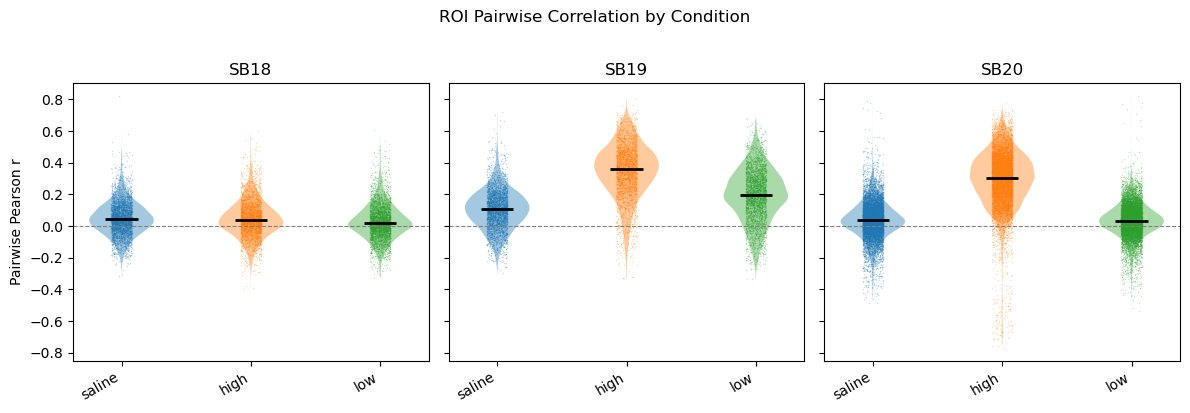

In [41]:
def compute_pairwise_correlations(dff_df, dataset, conditions=('saline', 'high', 'low')):
    """
    For each target condition and subject, compute the pairwise Pearson correlation
    matrix across all ROI dF/F traces and return the upper-triangle values.

    Returns a dict: {condition: {subject: 1-D array of pairwise r values}}
    """
    sc = dataset['session_config']['injection']
    results = {c: {} for c in conditions}

    for ses, task in dff_df.columns:
        condition = sc.xs(ses, level='Session').iloc[0]
        if condition not in conditions:
            continue
        for subject in dff_df.index:
            arr = dff_df.loc[subject, (ses, task)]  # (n_rois, n_timepoints)
            # Drop ROIs with any NaN
            no_nan = arr[~np.isnan(arr).any(axis=1)]
            # Drop zero-variance ROIs (would produce NaN in corrcoef)
            valid = no_nan[no_nan.std(axis=1) > 0]
            if valid.shape[0] < 2:
                print(f"  Skipping {subject} / {condition}: only {valid.shape[0]} valid ROI(s)")
                results[condition][subject] = np.array([])
                continue
            corr = np.corrcoef(valid)
            triu_idx = np.triu_indices_from(corr, k=1)
            results[condition][subject] = corr[triu_idx]

    return results


def plot_pairwise_correlations(corr_results):
    """
    One subplot per subject. Each subplot shows a violin + jitter per condition.
    """
    conditions = list(corr_results.keys())
    all_subjects = sorted({s for vals in corr_results.values() for s in vals})
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    cond_colors = [colors[i % len(colors)] for i in range(len(conditions))]
    rng = np.random.default_rng(1)

    fig, axes = plt.subplots(1, len(all_subjects), figsize=(4 * len(all_subjects), 4),
                             sharey=True)
    if len(all_subjects) == 1:
        axes = [axes]

    for ax, subject in zip(axes, all_subjects):
        plot_data = []
        for cond in conditions:
            r_vals = corr_results[cond].get(subject, np.array([]))
            plot_data.append(r_vals)

        # Only pass non-empty arrays to violinplot
        valid_idx = [i for i, v in enumerate(plot_data) if len(v) > 1]
        if valid_idx:
            parts = ax.violinplot([plot_data[i] for i in valid_idx],
                                  positions=valid_idx,
                                  showmedians=True, showextrema=False)
            for j, pc in enumerate(parts['bodies']):
                pc.set_facecolor(cond_colors[valid_idx[j]])
                pc.set_alpha(0.4)
            parts['cmedians'].set_color('black')
            parts['cmedians'].set_linewidth(2)

        for i, (vals, color) in enumerate(zip(plot_data, cond_colors)):
            if len(vals) == 0:
                continue
            jitter = rng.uniform(-0.08, 0.08, size=len(vals))
            ax.scatter(i + jitter, vals, s=1, color=color, alpha=0.25, linewidths=0)

        ax.set_xticks(np.arange(len(conditions)))
        ax.set_xticklabels(conditions, rotation=30, ha='right')
        ax.set_title(subject)
        ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')

    axes[0].set_ylabel('Pairwise Pearson r')
    fig.suptitle('ROI Pairwise Correlation by Condition', y=1.02)
    plt.tight_layout()
    plt.show()


corr_results = compute_pairwise_correlations(neuropil_sub, dataset)
plot_pairwise_correlations(corr_results)


In [43]:
# Phase 1: Total NaN count per subject across all sessions
for subject in neuropil_sub.index:
    total_nans = 0
    for col in neuropil_sub.columns:
        arr = neuropil_sub.loc[subject, col]
        if hasattr(arr, 'shape'):
            total_nans += int(np.isnan(arr).sum())
    print(f"{subject}: total NaN values = {total_nans}")


SB18: total NaN values = 0
SB19: total NaN values = 0
SB20: total NaN values = 0


In [44]:
# Phase 2: Which neurons are affected for SB20 — NaN density per session
subject = 'SB20'
for col in spont.columns:
    arr = spont.loc[subject, col]
    if hasattr(arr, 'shape') and arr.ndim == 2:
        nan_neurons = int(np.isnan(arr).any(axis=1).sum())
        total_neurons = arr.shape[0]
        nan_timepoints = int(np.isnan(arr).any(axis=0).sum())
        total_timepoints = arr.shape[1]
        print(f"{col}: {nan_neurons}/{total_neurons} neurons with NaN | {nan_timepoints}/{total_timepoints} timepoints with NaN")


('ses-01', 'task-grayscreen'): 0/308 neurons with NaN | 0/36000 timepoints with NaN
('ses-02', 'task-grayscreen'): 0/144 neurons with NaN | 0/36000 timepoints with NaN
('ses-03', 'task-grayscreen'): 0/144 neurons with NaN | 0/36000 timepoints with NaN
('ses-04', 'task-grayscreen'): 0/144 neurons with NaN | 0/36000 timepoints with NaN


In [16]:
# Phase 3: Check raw calcium source for SB20 — does NaN come from the dataset itself?
raw_sb20 = calcium.loc['SB20']
for col in raw_sb20.index:
    arr = raw_sb20[col]
    if hasattr(arr, 'shape'):
        n_nan = int(np.isnan(arr).sum())
        print(f"SB20 | {col}: {n_nan} NaN values, shape={arr.shape}")


SB20 | ('ses-01', 'task-grayscreen'): 0 NaN values, shape=(308, 36000)
SB20 | ('ses-02', 'task-grayscreen'): 0 NaN values, shape=(144, 36000)
SB20 | ('ses-03', 'task-grayscreen'): 0 NaN values, shape=(144, 36000)
SB20 | ('ses-04', 'task-grayscreen'): 0 NaN values, shape=(144, 36000)


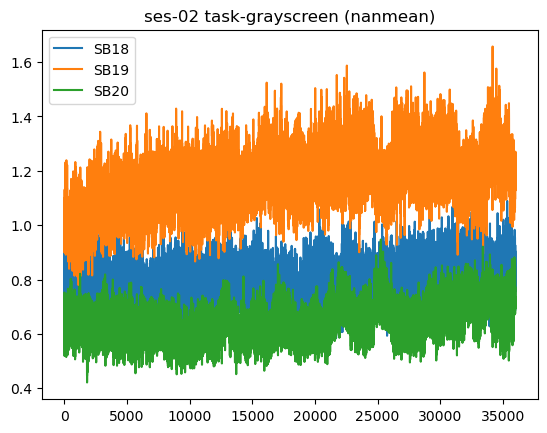

In [30]:
# Workaround: np.nanmean skips NaN — use this while diagnosing
for subject in spont_dff.index:
    plt.plot(np.nanmean(spont_dff['ses-03']['task-grayscreen'][subject], axis=0), label=subject)
plt.legend()
plt.title("ses-02 task-grayscreen (nanmean)")
plt.show()


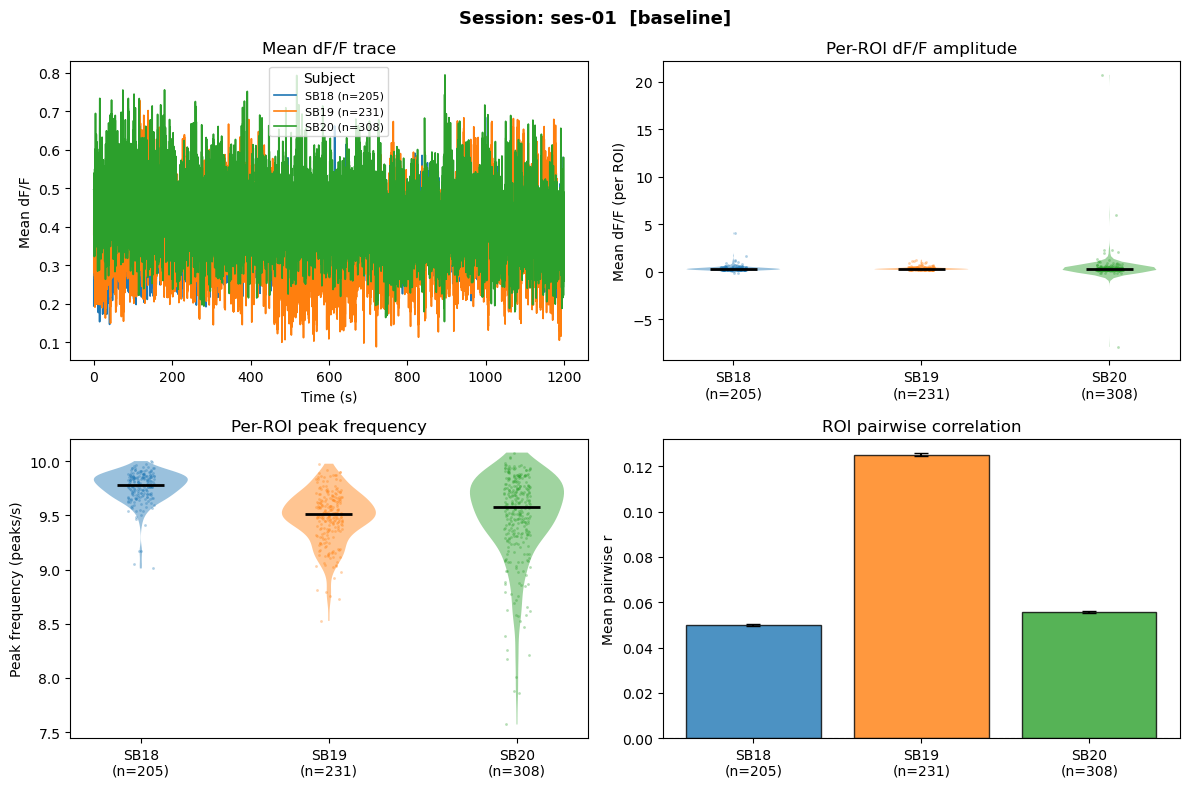

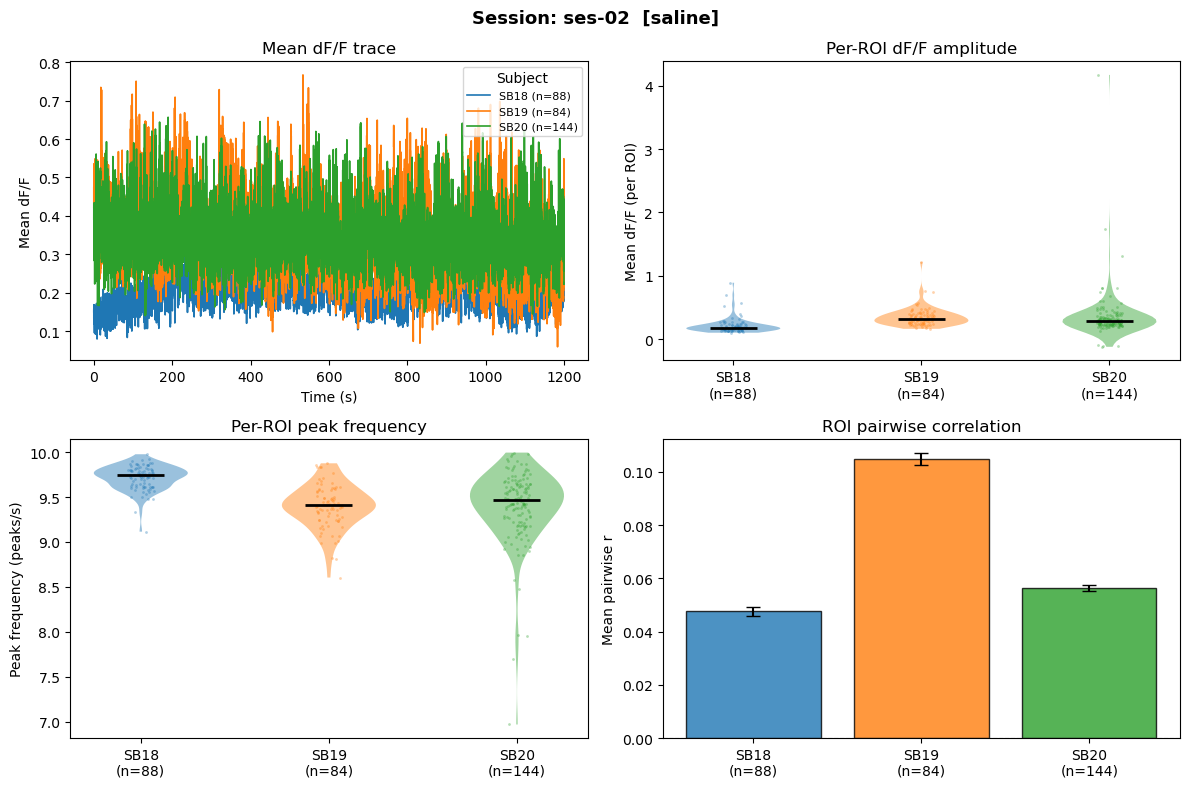

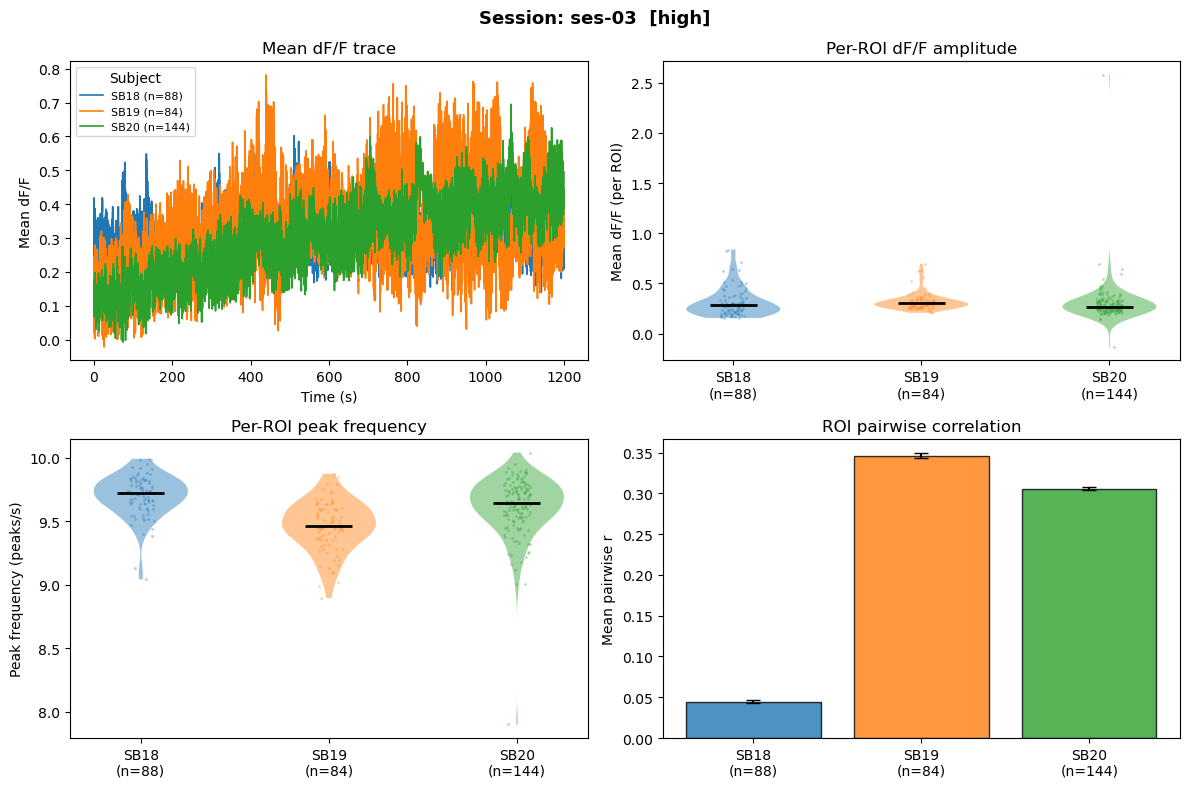

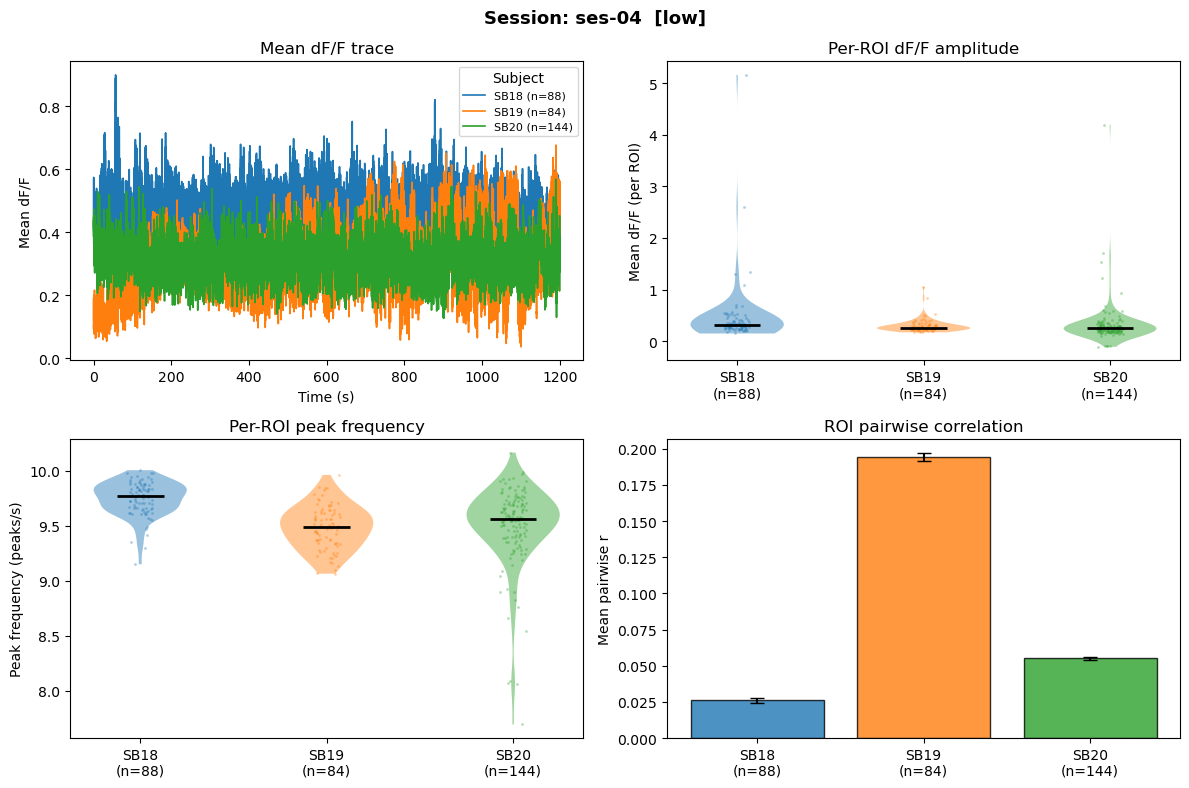

In [45]:
def plot_session_summary(session, dff_df, peaks_df, dataset, fs=30.0):
    """
    4-panel summary figure for a single session.

    Panels
    ------
    1. Mean dF/F trace (nanmean across ROIs vs time) — one line per subject.
    2. Per-ROI mean dF/F distribution — one violin/box per subject.
    3. Per-ROI peak frequency (peaks s⁻¹) — one violin/box per subject.
    4. Mean pairwise Pearson r of ROI traces — bar per subject.
    """
    sc = dataset['session_config']['injection']
    ses_cols = [c for c in dff_df.columns if c[0] == session]
    subjects = list(dff_df.index)
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    rng = np.random.default_rng(42)

    try:
        condition = sc.xs(session, level='Session').iloc[0]
        title_suffix = f"  [{condition}]"
    except Exception:
        title_suffix = ""

    # ROI count per subject (sum across all tasks in this session)
    n_rois = {subj: sum(dff_df.loc[subj, col].shape[0] for col in ses_cols) for subj in subjects}
    subj_labels = [f"{subj}\n(n={n_rois[subj]})" for subj in subjects]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Session: {session}{title_suffix}", fontsize=13, fontweight='bold')

    # ── Panel 1: mean dF/F trace ────────────────────────────────────────────
    ax1 = axes[0, 0]
    for i, subj in enumerate(subjects):
        traces = [np.nanmean(dff_df.loc[subj, col], axis=0) for col in ses_cols]
        mean_trace = np.nanmean(np.vstack(traces), axis=0)
        t = np.arange(len(mean_trace)) / fs
        ax1.plot(t, mean_trace, color=colors[i % len(colors)],
                 label=f"{subj} (n={n_rois[subj]})", linewidth=1.2)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Mean dF/F')
    ax1.set_title('Mean dF/F trace')
    ax1.legend(title='Subject', fontsize=8)

    # ── Panel 2: per-ROI mean dF/F distribution ─────────────────────────────
    ax2 = axes[0, 1]
    subj_roi_means = []
    for subj in subjects:
        vals = np.concatenate([np.nanmean(dff_df.loc[subj, col], axis=1) for col in ses_cols])
        subj_roi_means.append(vals)
    x_pos = np.arange(len(subjects))
    parts = ax2.violinplot(subj_roi_means, positions=x_pos, showmedians=True, showextrema=False)
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[j % len(colors)])
        pc.set_alpha(0.45)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    for j, (vals, color) in enumerate(zip(subj_roi_means, colors)):
        jitter = rng.uniform(-0.07, 0.07, size=len(vals))
        ax2.scatter(j + jitter, vals, s=4, color=color, alpha=0.35, linewidths=0)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(subj_labels)
    ax2.set_ylabel('Mean dF/F (per ROI)')
    ax2.set_title('Per-ROI dF/F amplitude')

    # ── Panel 3: per-ROI peak frequency ─────────────────────────────────────
    ax3 = axes[1, 0]
    subj_peak_freqs = []
    for subj in subjects:
        freqs = []
        for col in ses_cols:
            n_tp = dff_df.loc[subj, col].shape[1]
            dur = n_tp / fs
            freqs.extend(len(p) / dur for p in peaks_df.loc[subj, col])
        subj_peak_freqs.append(np.array(freqs))
    parts3 = ax3.violinplot(subj_peak_freqs, positions=x_pos, showmedians=True, showextrema=False)
    for j, pc in enumerate(parts3['bodies']):
        pc.set_facecolor(colors[j % len(colors)])
        pc.set_alpha(0.45)
    parts3['cmedians'].set_color('black')
    parts3['cmedians'].set_linewidth(2)
    for j, (vals, color) in enumerate(zip(subj_peak_freqs, colors)):
        jitter = rng.uniform(-0.07, 0.07, size=len(vals))
        ax3.scatter(j + jitter, vals, s=4, color=color, alpha=0.35, linewidths=0)
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(subj_labels)
    ax3.set_ylabel('Peak frequency (peaks/s)')
    ax3.set_title('Per-ROI peak frequency')

    # ── Panel 4: mean pairwise Pearson r ────────────────────────────────────
    ax4 = axes[1, 1]
    mean_r, sem_r = [], []
    for subj in subjects:
        r_vals = []
        for col in ses_cols:
            arr = dff_df.loc[subj, col]
            no_nan = arr[~np.isnan(arr).any(axis=1)]
            valid = no_nan[no_nan.std(axis=1) > 0]
            if valid.shape[0] >= 2:
                corr = np.corrcoef(valid)
                idx = np.triu_indices_from(corr, k=1)
                r_vals.extend(corr[idx].tolist())
        mean_r.append(np.mean(r_vals) if r_vals else np.nan)
        sem_r.append(np.std(r_vals, ddof=1) / np.sqrt(len(r_vals)) if len(r_vals) > 1 else np.nan)
    bars = ax4.bar(x_pos, mean_r, yerr=sem_r, capsize=5,
                   color=[colors[j % len(colors)] for j in range(len(subjects))],
                   edgecolor='black', alpha=0.8)
    for bar, subj in zip(bars, subjects):
        bar.set_label(subj)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(subj_labels)
    ax4.set_ylabel('Mean pairwise r')
    ax4.set_title('ROI pairwise correlation')
    ax4.axhline(0, color='grey', linewidth=0.8, linestyle='--')

    plt.tight_layout()
    plt.show()


# Run for every session present in spont_dff
for ses in spont_dff.columns.get_level_values('Session').unique():
    plot_session_summary(ses, spont_dff, peaks_df, dataset, fs=30.0)
